In [1]:
from vizdoom import *
import cv2
import numpy as np
import time
import random
from matplotlib import pyplot as plt
import pandas as pd
import os
from tqdm import tqdm
from collections import deque
import warnings

# Gym imports
import gymnasium as gym
from gymnasium import Env
from gymnasium.spaces import Discrete, Box

# Ollama imports
import requests
import json

# Hashing import fot the llm caching
import hashlib
from functools import lru_cache

# Stable Baseline loading
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.monitor import Monitor

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats      

In [2]:
# Instantiate TakeCover environment
CONFIG_PATH = './github/ViZDoom/scenarios/take_cover.cfg'
CACHE_PATH = './logs/policy_cache.json'
N_STACK     = 4         
N_EPISODES  = 1000       
SURVIVAL_THRESHOLD = 300
BOOTSTRAP_REPS     = 2000

COLORS = {
    "Baseline (No RS)":   "#3B82F6",
    "Baseline (RS)":      "#22C55E",
    "LLM Reward":         "#F97316",
    "LLM Policy":         "#A855F7",
}

In [3]:
# Create Vizdoom OpenAI Gym Environment
class VizDoomGym(Env): 
    def __init__(self):
        super().__init__()
        self.frame_skip = 4
        self.game = DoomGame()
        self.game.load_config(CONFIG_PATH)
        self.game.set_window_visible(False)
        self.game.set_living_reward(1)
        self.game.set_hit_taken_penalty(10)
        self.game.set_death_penalty(25)
        self.game.init()

        self.observation_space = Box(low=0, high=255, shape=(100, 160, 1), dtype=np.uint8)
        self.action_space      = Discrete(2)
        self._actions          = np.eye(2, dtype=np.uint8)

    def step(self, action):
        reward = self.game.make_action(self._actions[action].tolist(), self.frame_skip)
        if self.game.get_state():
            obs    = self._process_frame(self.game.get_state().screen_buffer)
            health = self.game.get_state().game_variables[0]
        else:
            obs    = np.zeros(self.observation_space.shape, dtype=np.uint8)
            health = 0
        terminated = self.game.is_episode_finished()
        return obs, reward, terminated, False, {"health": health}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.game.new_episode()
        state = self.game.get_state()
        obs = self._process_frame(state.screen_buffer) if state else \
              np.zeros(self.observation_space.shape, dtype=np.uint8)
        return obs, {}

    def get_survival_tics(self):
        return self.game.get_episode_time()

    def close(self):
        self.game.close()

    def _process_frame(self, buffer):
        hwc     = np.moveaxis(buffer, 0, -1)
        gray    = cv2.cvtColor(hwc, cv2.COLOR_RGB2GRAY)
        resized = cv2.resize(gray, (160, 100), interpolation=cv2.INTER_CUBIC)
        return np.clip(resized, 0, 255).astype(np.uint8).reshape(100, 160, 1)


In [4]:
class FrameStackWrapper:
    """
    Wraps a VizDoomGym and exposes stacked observations compatible with
    PPO models trained with VecFrameStack(..., channels_order='last').
    Stacked shape: (H, W, C*n_stack) = (100, 160, 4).
    """

    def __init__(self, env: VizDoomGym, n_stack: int = 4):
        self.env     = env
        self.n_stack = n_stack
        self._frames = deque(maxlen=n_stack)

    def reset(self):
        obs, info = self.env.reset()
        for _ in range(self.n_stack):
            self._frames.append(obs)
        return self._stack(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._frames.append(obs)
        return self._stack(), reward, terminated, truncated, info

    def get_survival_tics(self):
        return self.env.get_survival_tics()

    def close(self):
        self.env.close()

    def _stack(self):
        # shape: (H, W, C*n_stack)  –  same layout as VecFrameStack 'last'
        return np.concatenate(list(self._frames), axis=-1)

In [5]:
class PerceptionLayer:
    URGENCY_IMMINENT   =  150
    URGENCY_APPROACHING = 400
    SIDE_THRESHOLD = 15
    URGENCY_ENC = {"DISTANT": 0, "APPROACHING": 1, "IMMINENT": 2}
    SIDE_ENC    = {"CENTER": 0, "LEFT": 1, "RIGHT": 2}
    DIR_ENC     = {"PARALLEL TO": 0, "AWAY FROM": 1, "TOWARD": 2}
    HIT_ENC     = {None: 0, "HIT": 1, "FATAL": 2}
    MAX_PROJ    = 3

    ACTION_NAMES = {0: "LEFT", 1: "RIGHT"}

    def __init__(self):
        self.prev_health  = 100
        self.last_action  = None
        self.step_count   = 0

    def reset(self):
        self.prev_health = 100
        self.last_action = None
        self.step_count  = 0

    def update(self, state):
        self.step_count += 1

        player_y, health, hit = self._get_player_state(state)
        projectiles = self._get_projectiles(state, player_y)
        action = self.last_action
        state_text =  self._serialize(health, projectiles, hit, action)
        state_tag = self._get_state_tag(projectiles, hit, action)

        return state_text, state_tag
    
    def update_action(self, action):
        self.last_action = action
    
    def _get_player_state(self, state):
        vars = state.game_variables
        health = vars[0]
        player_y = vars[2]

        delta_h = health - self.prev_health
        self.prev_health = health
        hit = self._detect_hit(health, delta_h)

        return player_y, health, hit
    
    def _detect_hit(self, health, delta_h):
        if health <= 0:
            return "FATAL"
        if delta_h < 0:
            return "HIT"
        return None
    
    def _get_projectiles(self, state, player_y):
        projectiles = []
        for label in state.labels:
            if label.object_name == "DoomImpBall":
                delta_y = label.object_position_y - player_y
                delta_x = label.object_position_x
                projectiles.append({
                "delta_y": delta_y,
                "delta_x": delta_x,
                "side":    self._side(delta_y),
                "urgency": self._urgency(delta_x),
                })
        
        # Returns projectiles sorted by urgency (closest to player first)
        return sorted(projectiles, key=lambda p: abs(p["delta_x"]))
    
    def _side(self, delta_y: float):
        if abs(delta_y) < self.SIDE_THRESHOLD:
            return "CENTER"
        return "LEFT" if delta_y < 0 else "RIGHT"

    def _urgency(self, delta_x: float):
        dist = abs(delta_x)
        if dist < self.URGENCY_IMMINENT:
            return "IMMINENT"
        elif dist < self.URGENCY_APPROACHING:
            return "APPROACHING"
        return "DISTANT"
    
    def _evaluate_direction(self, action, threat_side):
        if threat_side == "CENTER":
            return "PARALLEL TO"
        if (threat_side == "RIGHT" and action == 1) or (threat_side == "LEFT" and action == 0):
            return "TOWARD"
        else:
            return "AWAY FROM"
    
    def _serialize(self, health, projectiles, hit, action):
        lines = []

        if not projectiles:
            return "No projectiles visible."
        else:
            if hit == "FATAL":
                lines.append("Health: 0/100 (DIED this step)")
            elif hit == "HIT":
                lines.append(f"Health: {int(health)}/100 (first hit, critical condition)")
            else:
                lines.append(f"Health: {int(health)}/100")
                
            lines.append(f"{len(projectiles)} projectile(s) detected:")
            for i, p in enumerate(projectiles, 1):
                if action is not None:
                    direction = self._evaluate_direction(action, p['side'])
                    lines.append(f"  {i}. {p['urgency'].upper()} threat on the {p['side']} side. The player MOVED {self.ACTION_NAMES.get(action)}. The player is MOVING {direction} this threat")
                else:
                    lines.append(f"  {i}. {p['urgency'].upper()} threat on the {p['side']} side")

        return "\n".join(lines)
    
    def _get_state_tag(self, projectiles, hit, action):
        hit_val = hit if hit else "NONE"
        act_val = self.ACTION_NAMES.get(action, "NONE")
        
        parts = [f"HIT:{hit_val}", f"ACT:{act_val}", f"NP:{len(projectiles)}"]
        
        for i, p in enumerate(projectiles):
            dir_val = self._evaluate_direction(action, p['side']) if action is not None else "NONE"
            p_str = f"P{i+1}:{p['urgency'][:4]},{p['side'][:4]},{dir_val[:4]}"
            parts.append(p_str)
            
        return " | ".join(parts)


In [6]:
class LLMPolicyAgent:
    CACHE_PATH = CACHE_PATH

    def __init__(self, model_name, backend_url):
        self.backend_url = backend_url
        self.model_name = model_name
        self.parse_failures = 0
        self._cache = {}
        self.payload = {
            "model" : self.model_name,
            "system" : self._build_system_prompt(),
            "prompt" : "",
            "stream" : False,
        }

        self._cache = self._load_cache()

    def decide(self, state_text, state_tag):
        key = hashlib.md5(state_tag.encode()).hexdigest()

        if key in self._cache:
            return self._cache[key]
        
        prompt = self._build_prompt(state_text)
        response = self._call_llm(prompt)
        action  = self._parse_action(response)

        self._cache[key] = action
        
        return action
    
    def _build_system_prompt(self):
        return """You are a policy model for a dodge game. The player must survive as long as possible by dodging fireballs shot by stationary enemies.
        The player can only move left or right.

        ### ALLOWED ACTIONS:
        - MOVE_LEFT: the player moves left.
        - MOVE_RIGHT: the player moves right.

        ### DECISION CRITERIA:
        - If a projectile is IMMINENT on your RIGHT side, move LEFT immediately.
        - If a projectile is IMMINENT on your LEFT side, move RIGHT immediately.
        - If a projectile is IMMINENT at CENTER, move in the direction with fewer total threats.
        - If multiple projectiles, prioritize the closest (listed first).
        - If no projectiles are visible, maintain current direction.

        ### OUTPUT FORMAT:
        Write the final line exactly as: ACTION: <action>"""
    
    def _build_prompt(self, state_text):
        return f"""### NOW EVALUATE: {state_text}"""

    def _call_llm(self, prompt):
        self.payload["prompt"] = prompt
        try:
            response = requests.post(self.backend_url, json= self.payload)

            # Check response status
            if response.status_code == 200:
                return response.json()["response"]
            else:
                print(f"Ollama returned error: {response.status_code}")
                return ""
        except requests.exceptions.ConnectionError:
            print("Failed to connect to Ollama backend.")
            return ""     
    
    def _parse_action(self, response):
        clean = response.strip().upper()
        if "MOVE_LEFT" in clean:
            return 0
        elif "MOVE_RIGHT" in clean:
            return 1
        else:
            # fallback: random action if parsing fails + log the failure
            self.parse_failures += 1
            return random.randint(0, 1)
        
    def _load_cache(self):
        if os.path.exists(self.CACHE_PATH):
            with open(self.CACHE_PATH, "r") as f:
                return json.load(f)
        return {}

    def _save_cache(self):
        with open(self.CACHE_PATH, "w") as f:
            json.dump(self._cache, f)

In [7]:
def make_eval_env():
    def _init():
        env = VizDoomGym(render=False)
        env = Monitor(env)
        return env
    return _init

In [ ]:
def _bootstrap_median_ci(data, reps=BOOTSTRAP_REPS, ci=0.95):
    """Return (lower, upper) bootstrap CI for the median."""
    medians = [np.median(np.random.choice(data, size=len(data), replace=True))
               for _ in range(reps)]
    alpha = (1 - ci) / 2
    return np.quantile(medians, alpha), np.quantile(medians, 1 - alpha)


def evaluate_agent(agent_fn, n_episodes=N_EPISODES, use_framestack=False,
                   perception: PerceptionLayer = None):
    """
    agent_fn(obs, raw_game_state_or_None) → int action
    use_framestack : True for PPO agents (they expect stacked obs)
    perception     : PerceptionLayer instance for LLM-Policy agent
    """
    raw_env = VizDoomGym()
    env     = FrameStackWrapper(raw_env, N_STACK) if use_framestack else raw_env

    survival_times  = []
    episode_rewards = []

    for _ in tqdm(range(n_episodes), leave=False):
        obs, _   = env.reset()
        if perception: perception.reset()
        done           = False
        episode_reward = 0.0

        while not done:
            # LLM agent needs the raw game state for label parsing
            game_state = raw_env.game.get_state() if not use_framestack else None
            action     = agent_fn(obs, game_state)

            obs, reward, done, _, _ = env.step(action)
            episode_reward         += reward

            if perception and not use_framestack and game_state:
                perception.update_action(action)

        # ── survival time: always from the engine ─────────────────────────
        survival_times.append(env.get_survival_tics() if use_framestack
                              else raw_env.get_survival_tics())
        episode_rewards.append(episode_reward)

    env.close()
    return np.array(survival_times), np.array(episode_rewards)


# STATS TABLE
def compute_stats(name, times, threshold):
    ci_lo, ci_hi = _bootstrap_median_ci(times)
    return {
        "Agent":      name,
        "Mean":       np.mean(times),
        "Std":        np.std(times),
        "Median":     np.median(times),
        "CI_lo":      ci_lo,
        "CI_hi":      ci_hi,
        "P25":        np.percentile(times, 25),
        "P75":        np.percentile(times, 75),
        "P95":        np.percentile(times, 95),
        f"% > {threshold}": 100 * np.mean(times > threshold),
    }


def print_stats_table(stats_list):
    header = f"{'Agent':<26} {'Mean':>7} {'Std':>7} {'Median':>8} " \
             f"{'95% CI':>16} {'IQR':>9} {'P95':>7} {'%>thr':>7}"
    print("\n" + "─" * len(header))
    print(header)
    print("─" * len(header))
    for s in stats_list:
        iqr = s["P75"] - s["P25"]
        ci  = f"[{s['CI_lo']:.0f}, {s['CI_hi']:.0f}]"
        pct = list(s.values())[-1]        # last key is "% > threshold"
        print(f"{s['Agent']:<26} {s['Mean']:>7.1f} {s['Std']:>7.1f} "
              f"{s['Median']:>8.1f} {ci:>16} {iqr:>9.1f} {s['P95']:>7.1f} {pct:>6.1f}%")
    print("─" * len(header))


# PLOT  (KDE ridge + box + stat annotation)
def plot_results(results: dict[str, np.ndarray], save_path: str = "./logs/survival_analysis.png"):
    names  = list(results.keys())
    n = len(names)
    colors = [COLORS.get(k, "#888780") for k in names]

    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    fig.patch.set_facecolor("#FAFAF8")

    def _style(ax):
        ax.set_facecolor("#FAFAF8")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#D3D1C7")
        ax.tick_params(colors="#5F5E5A", labelsize=9)

    all_times = np.concatenate(list(results.values()))
    t_max = int(np.max(all_times))

    # Survival curve  P(T ≥ t)
    ax = axes[0]; _style(ax)
    t_disc = np.arange(0, t_max + 1)
    for name, color in zip(names, colors):
        arr   = results[name]
        surv  = np.array([np.mean(arr >= t) for t in t_disc])
        ax.plot(t_disc, surv * 100, color=color, linewidth=2, label=name)

    ax.axvline(SURVIVAL_THRESHOLD, color="#888780", linewidth=1, linestyle=":", label=f"threshold {SURVIVAL_THRESHOLD}")
    ax.set_xlabel("Survival Time (tics)", fontsize=10, color="#444441")
    ax.set_ylabel("Survived Episodes (%)", fontsize=10, color="#444441")
    ax.set_title("Survival Curve\nP(T ≥ t)", fontsize=11, color="#2C2C2A", fontweight="500", pad=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis="y", color="#E0DED8", linewidth=0.5, linestyle="--")

    # Box
    ax = axes[1]; _style(ax)
    data   = [results[n] for n in names]
    bp = ax.boxplot(data, patch_artist=True, widths=0.45, medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="#B4B2A9", linewidth=1), capprops=dict(color="#B4B2A9", linewidth=1),
                    flierprops=dict(marker=".", markersize=2, alpha=0))

    rng = np.random.default_rng(42)
    for i, (d, color) in enumerate(zip(data, colors), 1):
        bp["boxes"][i-1].set_facecolor(color)
        bp["boxes"][i-1].set_alpha(0.80)
        med = np.median(d)
        ax.text(i, med + t_max * 0.01, f"{med:.0f}", ha="center", va="bottom", fontsize=8, color="black", fontweight="600")

    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=8, color="#444441")
    ax.set_ylabel("Survival Time (tics)", fontsize=10, color="#444441")
    ax.set_title("Survival Time Boxplot", fontsize=11, color="#2C2C2A", fontweight="500", pad=10)
    ax.grid(axis="y", color="#E0DED8", linewidth=0.5, linestyle="--")

    plt.tight_layout(pad=2.5)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nPlot salvato in: {save_path}")


In [9]:
ppo_no_rs  = PPO.load('models/no_rewshap/best_model.zip')
ppo_rs     = PPO.load('models/rewshap/best_model.zip')
ppo_llmrew = PPO.load('models/llm_reward/best_model.zip')

perception  = PerceptionLayer()
llm_agent   = LLMPolicyAgent(model_name="llama3.2:3b", backend_url="http://localhost:11434/api/generate")

def make_ppo_fn(model):
    def fn(obs, _game_state):
        action, _ = model.predict(obs[np.newaxis], deterministic=True)
        return int(action[0])
    return fn

def llm_policy_fn(obs, game_state):
    if game_state is None:
        return random.randint(0, 1)
    state_text, state_tag = perception.update(game_state)
    action = llm_agent.decide(state_text, state_tag)
    perception.update_action(action)
    return action

In [10]:
# Computing survival threshold
baseline_times, _ = evaluate_agent(make_ppo_fn(ppo_no_rs), n_episodes=100, use_framestack=True, perception=None)
SURVIVAL_THRESHOLD = int(np.percentile(baseline_times, 25))

print(f"Dynamic Survival Threshold (P25 Baseline): {SURVIVAL_THRESHOLD} tics\n")

Dynamic Survival Threshold (P25 Baseline): 541 tics



In [11]:
agents = [
    ("Baseline (No RS)", make_ppo_fn(ppo_no_rs),  True,  None),
    ("Baseline (RS)",    make_ppo_fn(ppo_rs),      True,  None),
    ("LLM Reward",       make_ppo_fn(ppo_llmrew),  True,  None),
    ("LLM Policy",       llm_policy_fn,            False, perception),
]

survival_data = {}
stats_list    = []

for name, fn, use_fs, perc in agents:
    print(f"\nEvaluating: {name}")
    start_time = time.time()
    times, rewards = evaluate_agent(fn, n_episodes=N_EPISODES, use_framestack=use_fs, perception=perc)
    end_time = time.time()
    elap_time = end_time - start_time
    print(f"Total evaluation time: {elap_time:.2f}sec")
    end_time = time.time()
    survival_data[name] = times
    stats_list.append(compute_stats(name, times, SURVIVAL_THRESHOLD))


Evaluating: Baseline (No RS)


Total evaluation time: 1271.49sec

Evaluating: Baseline (RS)


Total evaluation time: 1129.84sec

Evaluating: LLM Reward


Total evaluation time: 1251.37sec

Evaluating: LLM Policy


Total evaluation time: 2042.92sec


In [12]:
print_stats_table(stats_list)


──────────────────────────────────────────────────────────────────────────────────────────────
Agent                         Mean     Std   Median           95% CI       IQR     P95   %>thr
──────────────────────────────────────────────────────────────────────────────────────────────
Baseline (No RS)             980.0   645.7    823.0       [789, 866]     852.5  2269.2   72.2%
Baseline (RS)                867.2   529.0    761.0       [718, 796]     729.0  1897.1   68.2%
LLM Reward                   979.0   658.3    838.0       [799, 875]     771.8  2293.7   72.0%
LLM Policy                   284.7    64.5    277.0       [272, 282]      82.0   400.0    0.3%
──────────────────────────────────────────────────────────────────────────────────────────────


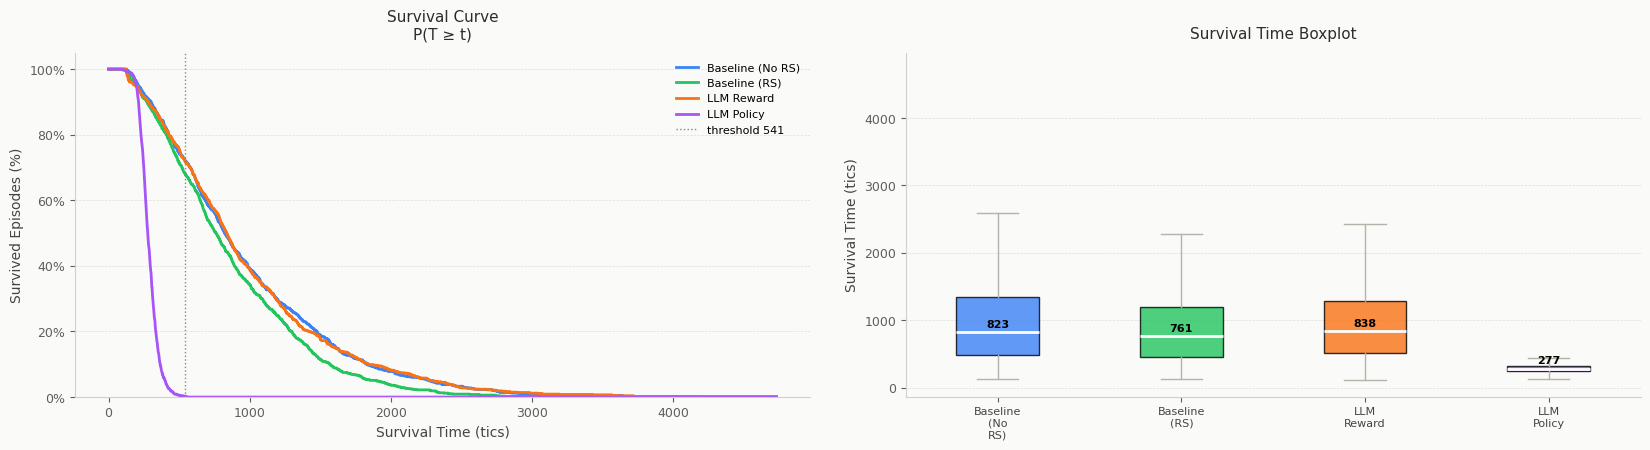


Plot salvato in: ./logs/survival_analysis.png


In [25]:
plot_results(survival_data)